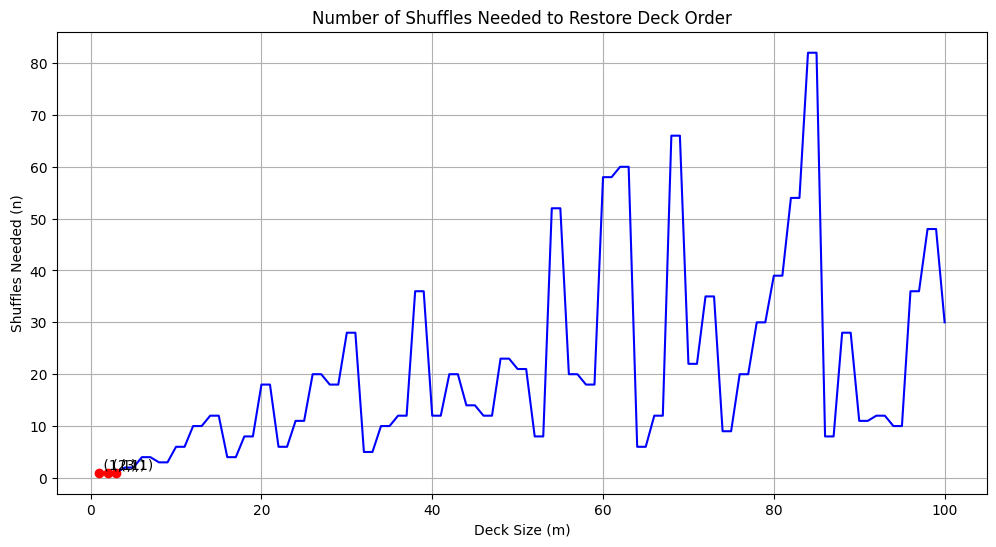

In [3]:
import matplotlib.pyplot as plt

def find_shuffle_count(m):
    original = list(range(1, m+1))
    cards = original.copy()
    count = 0
    
    while True:
        # Perform the shuffle
        top = cards[:m//2]
        bottom = cards[m//2:]
        cards = []
        for i in range(max(len(top), len(bottom))):
            if i < len(top):
                cards.append(top[i])
            if i < len(bottom):
                cards.append(bottom[i])
        
        count += 1
        
        # Check if back to original
        if cards == original:
            return count

# Calculate for m from 1 to 1000
m_values = list(range(1, 101))
n_values = [find_shuffle_count(m) for m in m_values]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(m_values, n_values, 'b-')
plt.xlabel('Deck Size (m)')
plt.ylabel('Shuffles Needed (n)')
plt.title('Number of Shuffles Needed to Restore Deck Order')
plt.grid(True)

# Find and mark some interesting points
interesting_ms = []
for m in range(1, 101):
    n = find_shuffle_count(m)
    if m == n or n == 1 or (m > 2 and n == m - 1):
        interesting_ms.append((m, n))

for m, n in interesting_ms:
    plt.plot(m, n, 'ro')
    plt.text(m, n, f' ({m},{n})', verticalalignment='bottom')

plt.show()

In [4]:
import matplotlib.pyplot as plt
from sympy import n_order  # 计算乘法阶数（优化计算）


def find_shuffle_count(m):
    original = list(range(1, m+1))
    cards = original.copy()
    count = 0
    
    while True:
        # Perform the shuffle
        top = cards[:m//2]
        bottom = cards[m//2:]
        cards = []
        for i in range(max(len(top), len(bottom))):
            if i < len(top):
                cards.append(top[i])
            if i < len(bottom):
                cards.append(bottom[i])
        
        count += 1
        
        # Check if back to original
        if cards == original:
            return count

# 计算m=1~1000的n值
m_values = list(range(1, 1112))
n_values = [find_shuffle_count(m) for m in m_values]
# 可视化中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
import plotly.graph_objects as go

# Create the plotly figure
fig = go.Figure()
fig.add_trace(go.Scatter(x=m_values, y=n_values, mode='lines', name='洗牌次数'))

# Update layout with Chinese labels
fig.update_layout(
    title='牌组大小 vs. 恢复初始顺序所需洗牌次数',
    xaxis_title='牌组大小 (m)',
    yaxis_title='洗牌次数 (n)',
    showlegend=True,
    width=1200,
    height=600
)

# Add grid
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

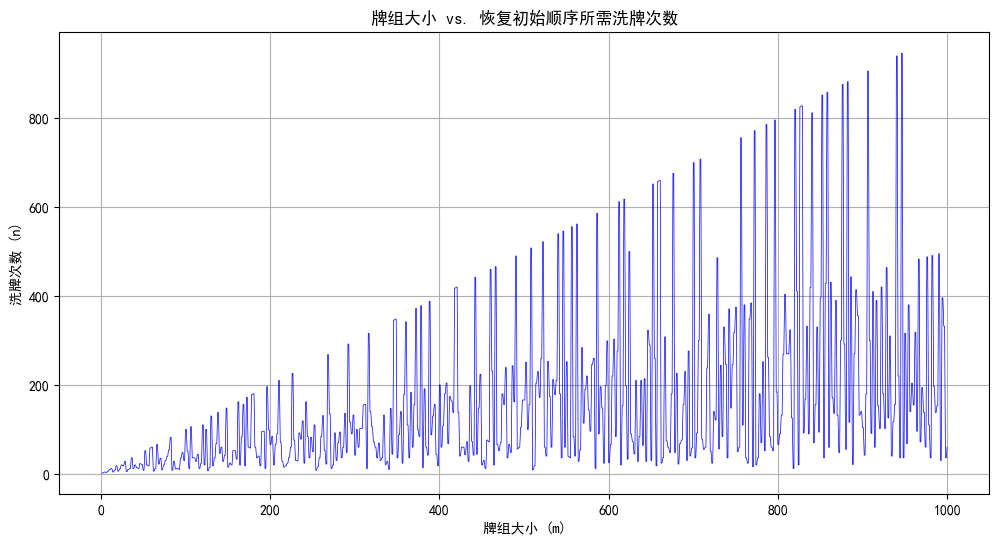

In [5]:
import matplotlib.pyplot as plt
from sympy import n_order  # 计算乘法阶数（优化计算）

def find_shuffle_count(m):
    if m == 1:
        return 1
    # 数学优化：n = 2在模(m)或模(m+1)下的乘法阶数
    return n_order(2, m if m % 2 == 1 else m + 1)

# 计算m=1~1000的n值
m_values = list(range(1, 1001))
n_values = [find_shuffle_count(m) for m in m_values]

# 绘制曲线
plt.figure(figsize=(12, 6))
plt.plot(m_values, n_values, 'b-', linewidth=0.5)
plt.xlabel('牌组大小 (m)')
plt.ylabel('洗牌次数 (n)')
plt.title('牌组大小 vs. 恢复初始顺序所需洗牌次数')
plt.grid(True)
plt.show()

In [6]:
#输出数组
print("m_values:", m_values)
print("n_values:", n_values)

m_values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

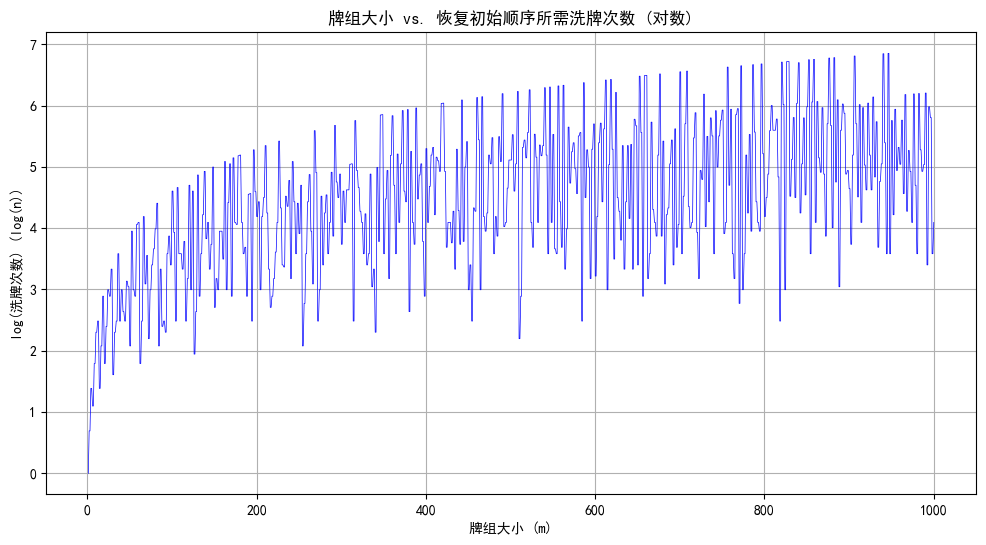

In [7]:
#转为log再可视化
import numpy as np
# 转换为对数
log_n_values = np.log(n_values)
# 绘制对数曲线
plt.figure(figsize=(12, 6))
plt.plot(m_values, log_n_values, 'b-', linewidth=0.5)
plt.xlabel('牌组大小 (m)')
plt.ylabel('log(洗牌次数) (log(n))')
plt.title('牌组大小 vs. 恢复初始顺序所需洗牌次数 (对数)')
plt.grid(True)  